In [1]:
#Importación librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#Importación de Machin Learning
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Clustering jerárquico (dendrograma)
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
#Ruta
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

#Cargar datos
df = pd.read_csv("CC_GENERAL.csv")

#Visualización inicial
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
#EDA-Información general
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
#EDA-Valores nulos
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
#EDA-Valores faltantes
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)

C:\Users\Nefi\AppData\Local\Temp\ipykernel_19176\4050030542.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
C:\Users\Nefi\AppData\Local\Temp\ipykernel_19176\4050030542.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [7]:
#Eliminación de duplicados
df = df.drop_duplicates()

In [8]:
#Eliminación de variable
df = df.drop_duplicates()

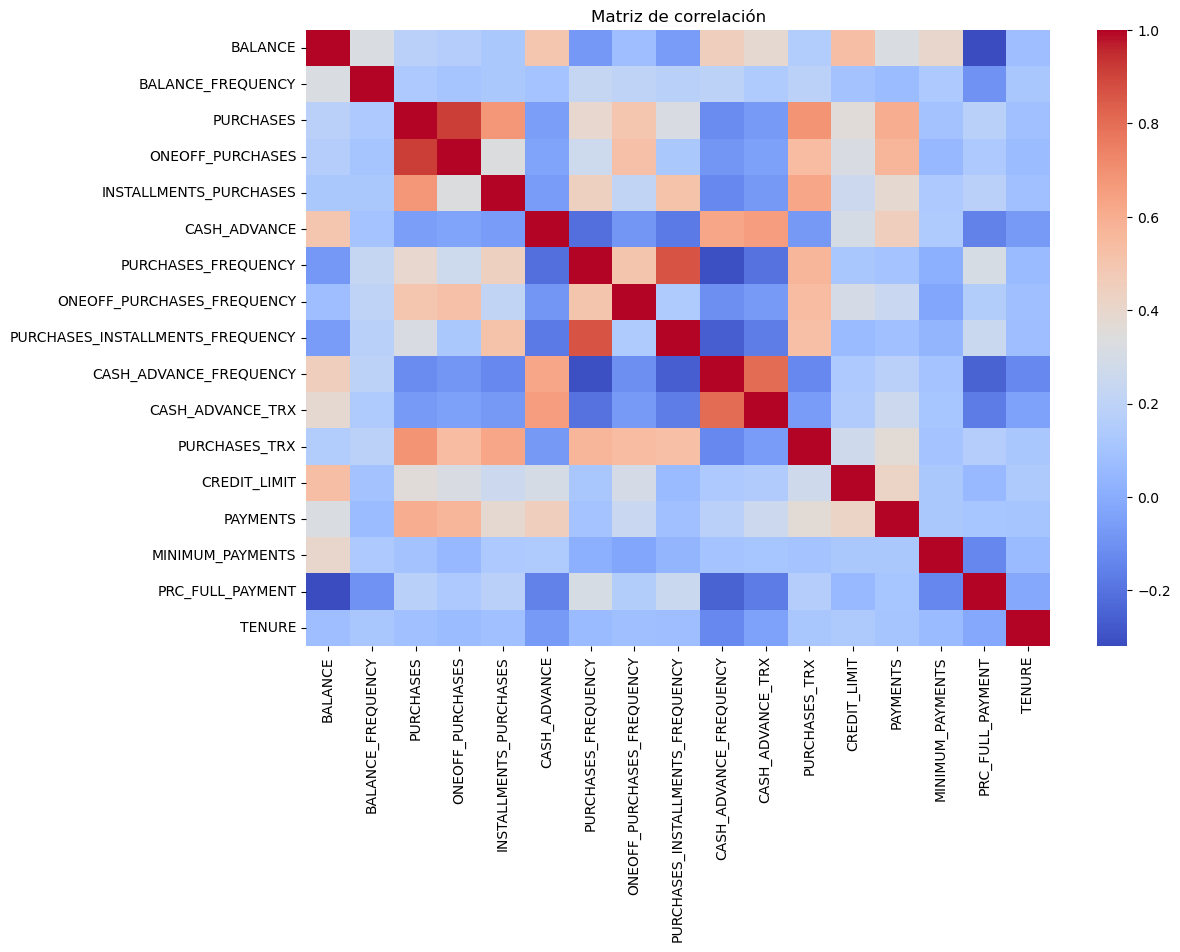

In [10]:
#Análisis de correlación
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=['float64','int64']).corr(), cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

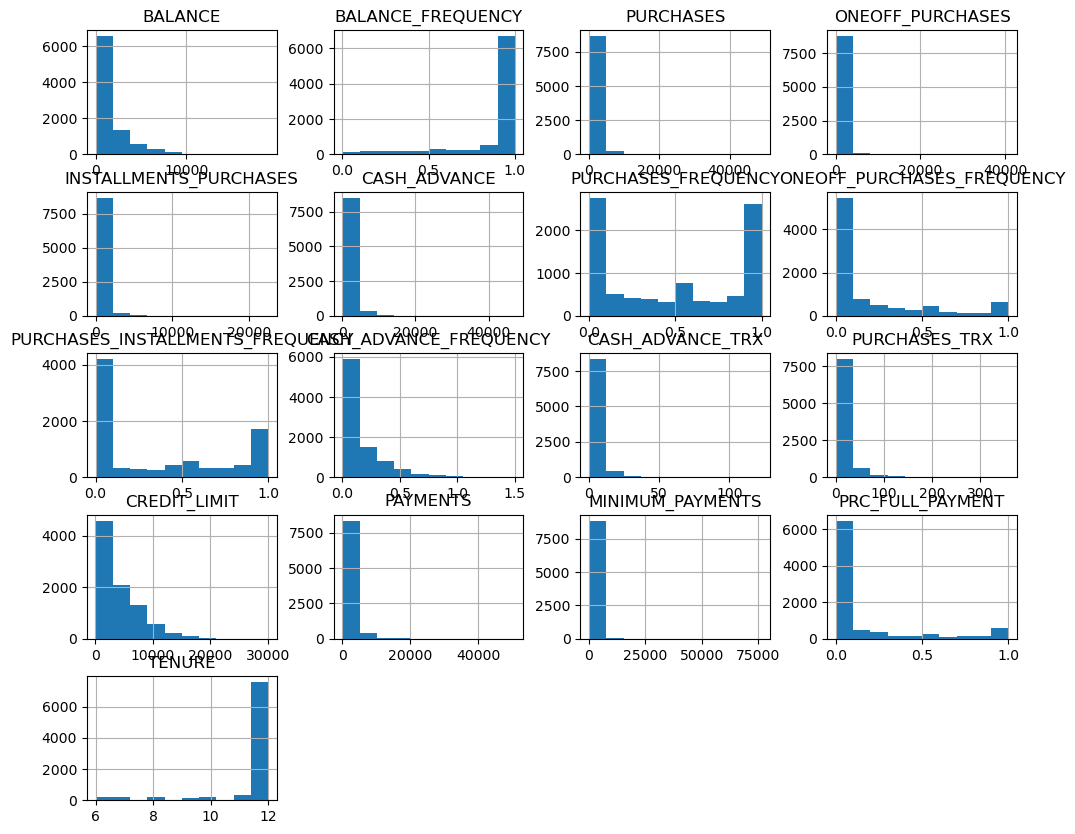

In [11]:
#Distribución de variabless
df.hist(figsize=(12,10))
plt.show()

In [12]:
#ML-Nueva variable: ratio de uso del crédito
df["CREDIT_USAGE_RATIO"] = df["BALANCE"] / df["CREDIT_LIMIT"]

In [13]:
#ML-Nueva variable: compras totales relativas
df["PURCHASE_RATIO"] = df["PURCHASES"] / (df["PAYMENTS"] + 1)

In [15]:
df.drop("CUST_ID", axis=1, inplace=True)

In [18]:
#Estandarización Zscore
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

In [19]:
#Método Elbow
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(df_scaled)
    
    wcss.append(kmeans.inertia_)

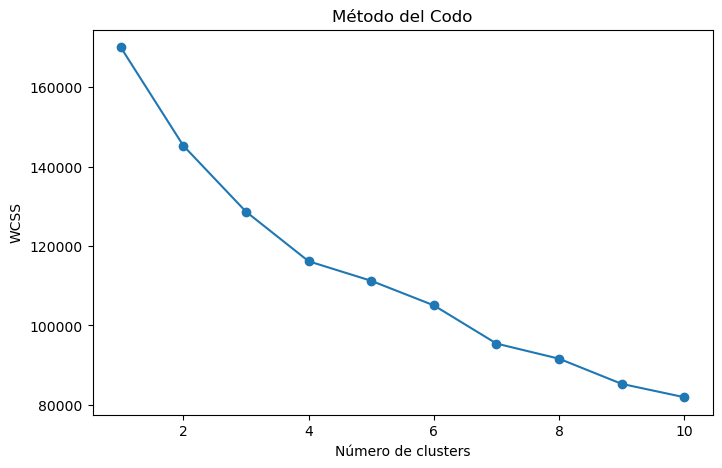

In [20]:
#Gráfica del método
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Número de clusters")
plt.ylabel("WCSS")

plt.title("Método del Codo")

plt.show()

In [21]:
#Entrenamiento usando K4
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(df_scaled)

df["Cluster"] = clusters

In [22]:
#Evaluación con Silhouette Score
score = silhouette_score(df_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.182513888982799


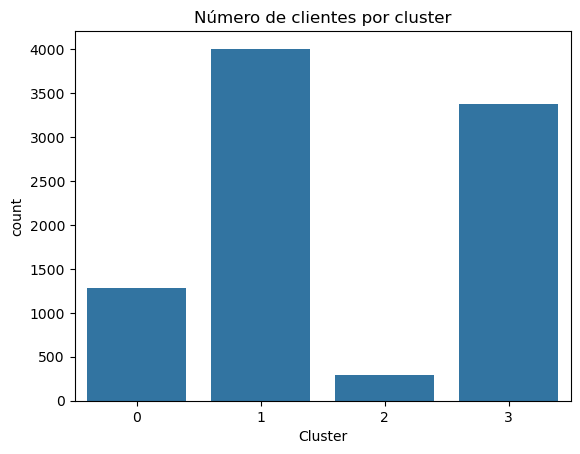

In [23]:
#Distribución de clientes por cluster
sns.countplot(x=df["Cluster"])

plt.title("Número de clientes por cluster")

plt.show()

In [24]:
#Perfilamiento
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CREDIT_USAGE_RATIO,PURCHASE_RATIO
Cluster,,,,,,,,,,,,,,,,,,,
0,4555.972447,0.970993,505.391306,318.057866,187.412932,4340.171284,0.288949,0.136187,0.188226,0.473594,13.780297,7.774042,7330.105196,3353.636386,2115.976722,0.032330,11.397185,0.659050,5.970972
1,988.857082,0.790896,279.873188,214.187302,66.025494,575.958741,0.181176,0.088918,0.089308,0.110487,2.044683,3.134299,3237.844067,971.293544,545.030545,0.077313,11.448078,0.404369,11.101750
2,3983.834854,0.985153,9050.189654,6026.470311,3025.795467,790.517875,0.944642,0.741108,0.792042,0.078688,2.401384,99.141869,10441.003460,8650.451955,2377.864894,0.287345,11.951557,0.393146,1.449452
3,907.070855,0.935022,1361.259177,680.045678,681.398477,199.664396,0.894632,0.316181,0.721062,0.041014,0.760367,23.845379,4401.768440,1431.088266,587.969791,0.278921,11.607820,0.267792,16.179807


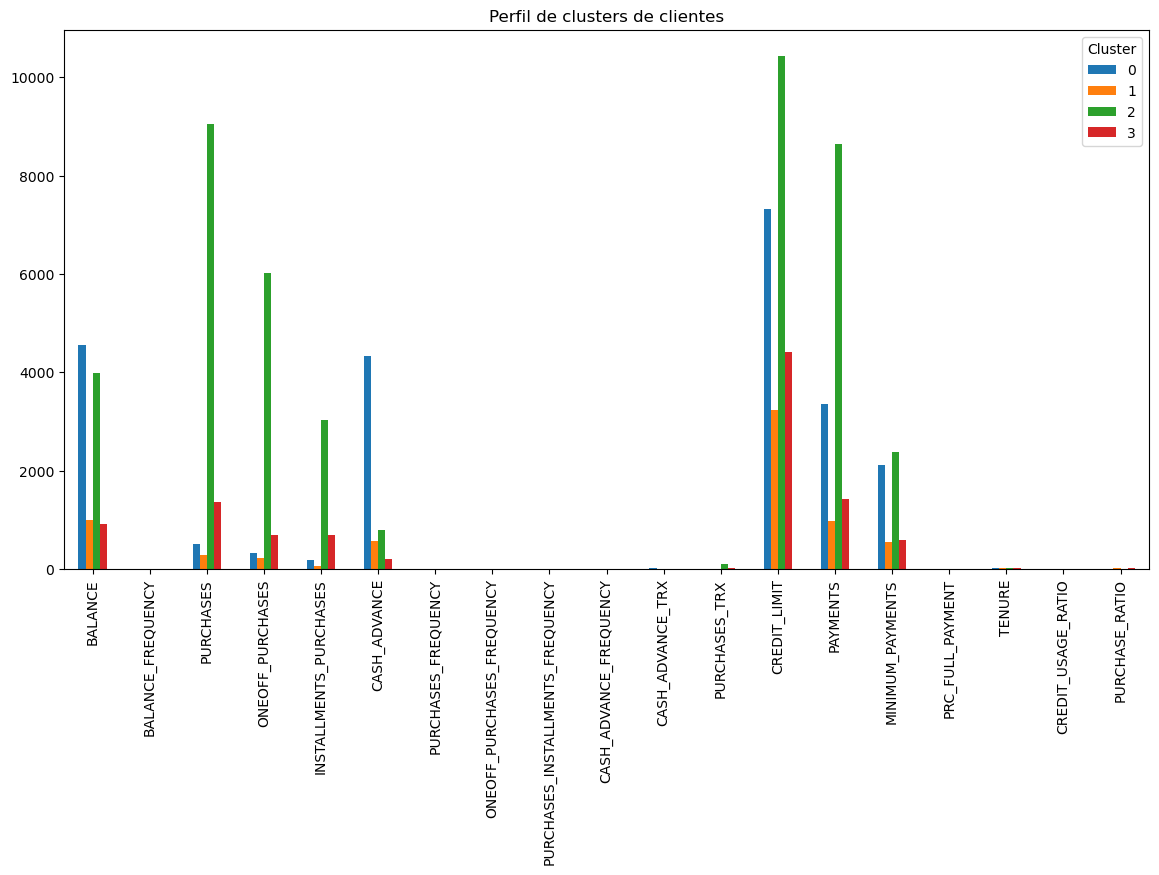

In [25]:
#Visualización del perfil
cluster_profile.T.plot(
    kind="bar",
    figsize=(14,7)
)

plt.title("Perfil de clusters de clientes")

plt.show()

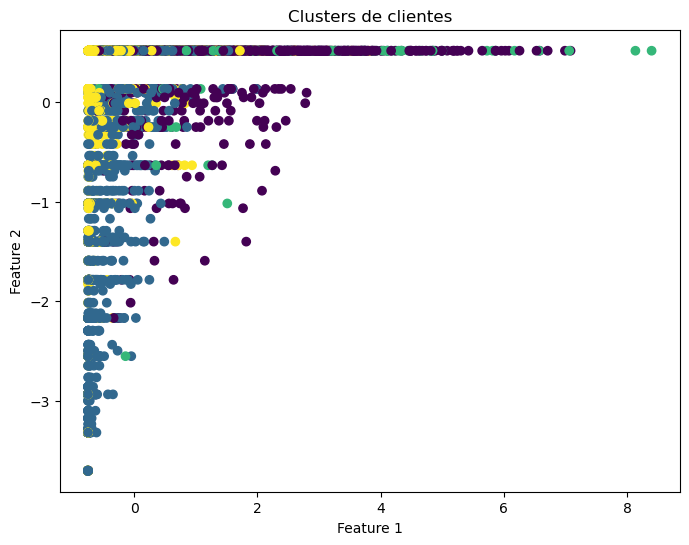

In [26]:
#Visualización de disperción
plt.figure(figsize=(8,6))

plt.scatter(
    df_scaled[:,0],
    df_scaled[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Clusters de clientes")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

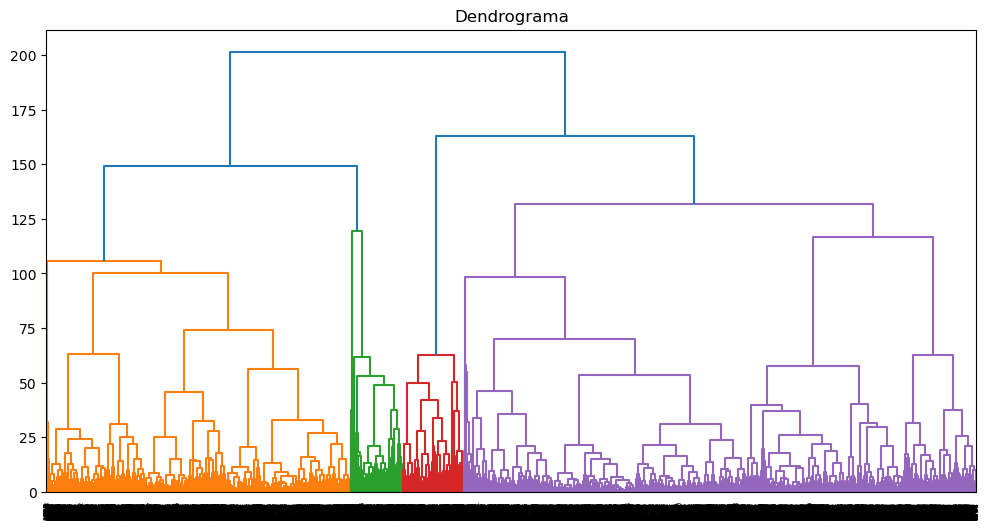

In [27]:
#Validación con dendrograma
linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrograma")

plt.show()